In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
DATA_PATH = Path("../data/raw/creditcard.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset at: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Number of duplicate rows:", df.duplicated().sum())
print("\nMissing values:")
display(missing if len(missing) > 0 else pd.Series(dtype=int, name="No missing values"))

Number of duplicate rows: 1081

Missing values:


Series([], Name: No missing values, dtype: int64)

In [6]:
duplicate_rows = df[df.duplicated()]
print("Duplicate row count:", len(duplicate_rows))
duplicate_rows["Class"].value_counts()

Duplicate row count: 1081


Class
0    1062
1      19
Name: count, dtype: int64

In [7]:
print("Original shape:", df.shape)
print("Original class distribution:")
print(df["Class"].value_counts())

df_nodup = df.drop_duplicates()

print("\nAfter removing duplicates:", df_nodup.shape)
print("Class distribution after removing duplicates:")
print(df_nodup["Class"].value_counts())

Original shape: (284807, 31)
Original class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

After removing duplicates: (283726, 31)
Class distribution after removing duplicates:
Class
0    283253
1       473
Name: count, dtype: int64


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0000,94813.8596,47488.1460,0.0000,54201.5000,84692.0000,139320.5000,172792.0000
V1,284807.0000,0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,284807.0000,0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,284807.0000,-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,284807.0000,0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,284807.0000,0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,284807.0000,0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,284807.0000,-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,284807.0000,0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,284807.0000,-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


In [9]:
class_counts = df["Class"].value_counts().sort_index()
class_percent = df["Class"].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    "count": class_counts,
    "percent": class_percent
})
summary.index = ["Non-Fraud (0)", "Fraud (1)"]
summary

,count,percent
Non-Fraud (0),284315,99.8273
Fraud (1),492,0.1727


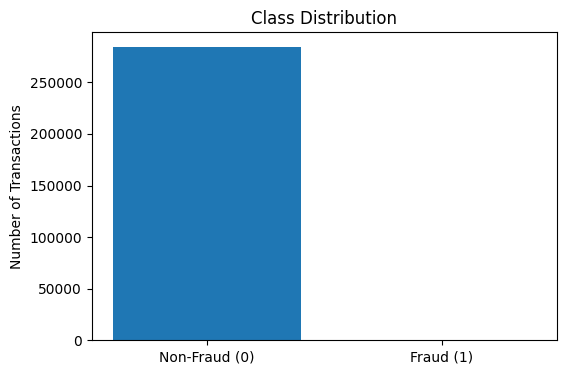

Fraud rate: 0.1727%


In [10]:
plt.figure(figsize=(6, 4))
plt.bar(["Non-Fraud (0)", "Fraud (1)"], class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Number of Transactions")
plt.show()

print(f"Fraud rate: {df['Class'].mean() * 100:.4f}%")

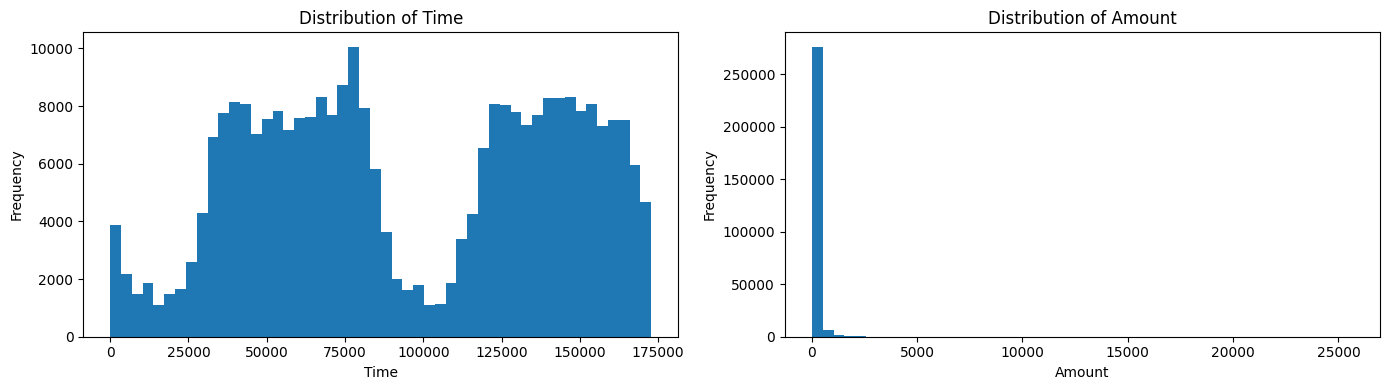

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["Time"], bins=50)
axes[0].set_title("Distribution of Time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["Amount"], bins=50)
axes[1].set_title("Distribution of Amount")
axes[1].set_xlabel("Amount")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

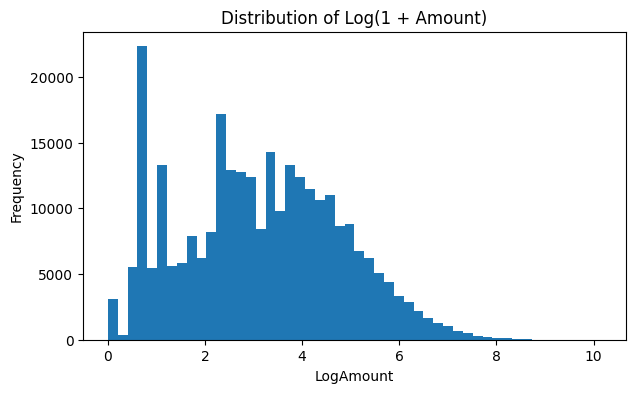

In [12]:
df["LogAmount"] = np.log1p(df["Amount"])

plt.figure(figsize=(7, 4))
plt.hist(df["LogAmount"], bins=50)
plt.title("Distribution of Log(1 + Amount)")
plt.xlabel("LogAmount")
plt.ylabel("Frequency")
plt.show()

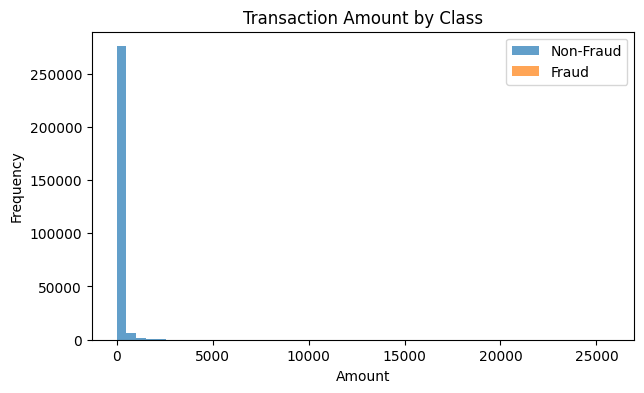

In [13]:
fraud_amount = df.loc[df["Class"] == 1, "Amount"]
nonfraud_amount = df.loc[df["Class"] == 0, "Amount"]

plt.figure(figsize=(7, 4))
plt.hist(nonfraud_amount, bins=50, alpha=0.7, label="Non-Fraud")
plt.hist(fraud_amount, bins=50, alpha=0.7, label="Fraud")
plt.title("Transaction Amount by Class")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

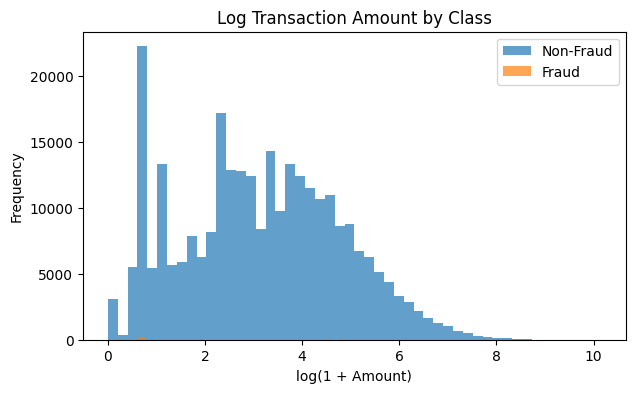

In [14]:
fraud_log_amount = np.log1p(df.loc[df["Class"] == 1, "Amount"])
nonfraud_log_amount = np.log1p(df.loc[df["Class"] == 0, "Amount"])

plt.figure(figsize=(7, 4))
plt.hist(nonfraud_log_amount, bins=50, alpha=0.7, label="Non-Fraud")
plt.hist(fraud_log_amount, bins=50, alpha=0.7, label="Fraud")
plt.title("Log Transaction Amount by Class")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

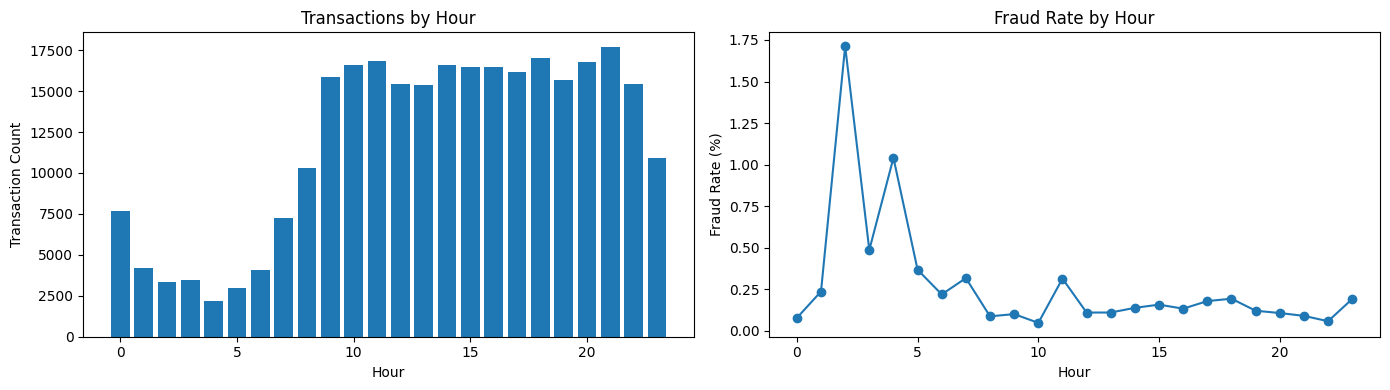

In [15]:
df["Hour"] = (df["Time"] // 3600) % 24

hourly = df.groupby("Hour")["Class"].agg(["count", "mean"]).reset_index()
hourly["fraud_percent"] = hourly["mean"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(hourly["Hour"], hourly["count"])
axes[0].set_title("Transactions by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Transaction Count")

axes[1].plot(hourly["Hour"], hourly["fraud_percent"], marker="o")
axes[1].set_title("Fraud Rate by Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

In [16]:
corr_with_target = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
corr_with_target.head(10), corr_with_target.tail(10)

(Class   1.0000
 V11     0.1549
 V4      0.1334
 V2      0.0913
 V21     0.0404
 V19     0.0348
 V20     0.0201
 V8      0.0199
 V27     0.0176
 V28     0.0095
 Name: Class, dtype: float64,
 V9    -0.0977
 V1    -0.1013
 V18   -0.1115
 V7    -0.1873
 V3    -0.1930
 V16   -0.1965
 V10   -0.2169
 V12   -0.2606
 V14   -0.3025
 V17   -0.3265
 Name: Class, dtype: float64)

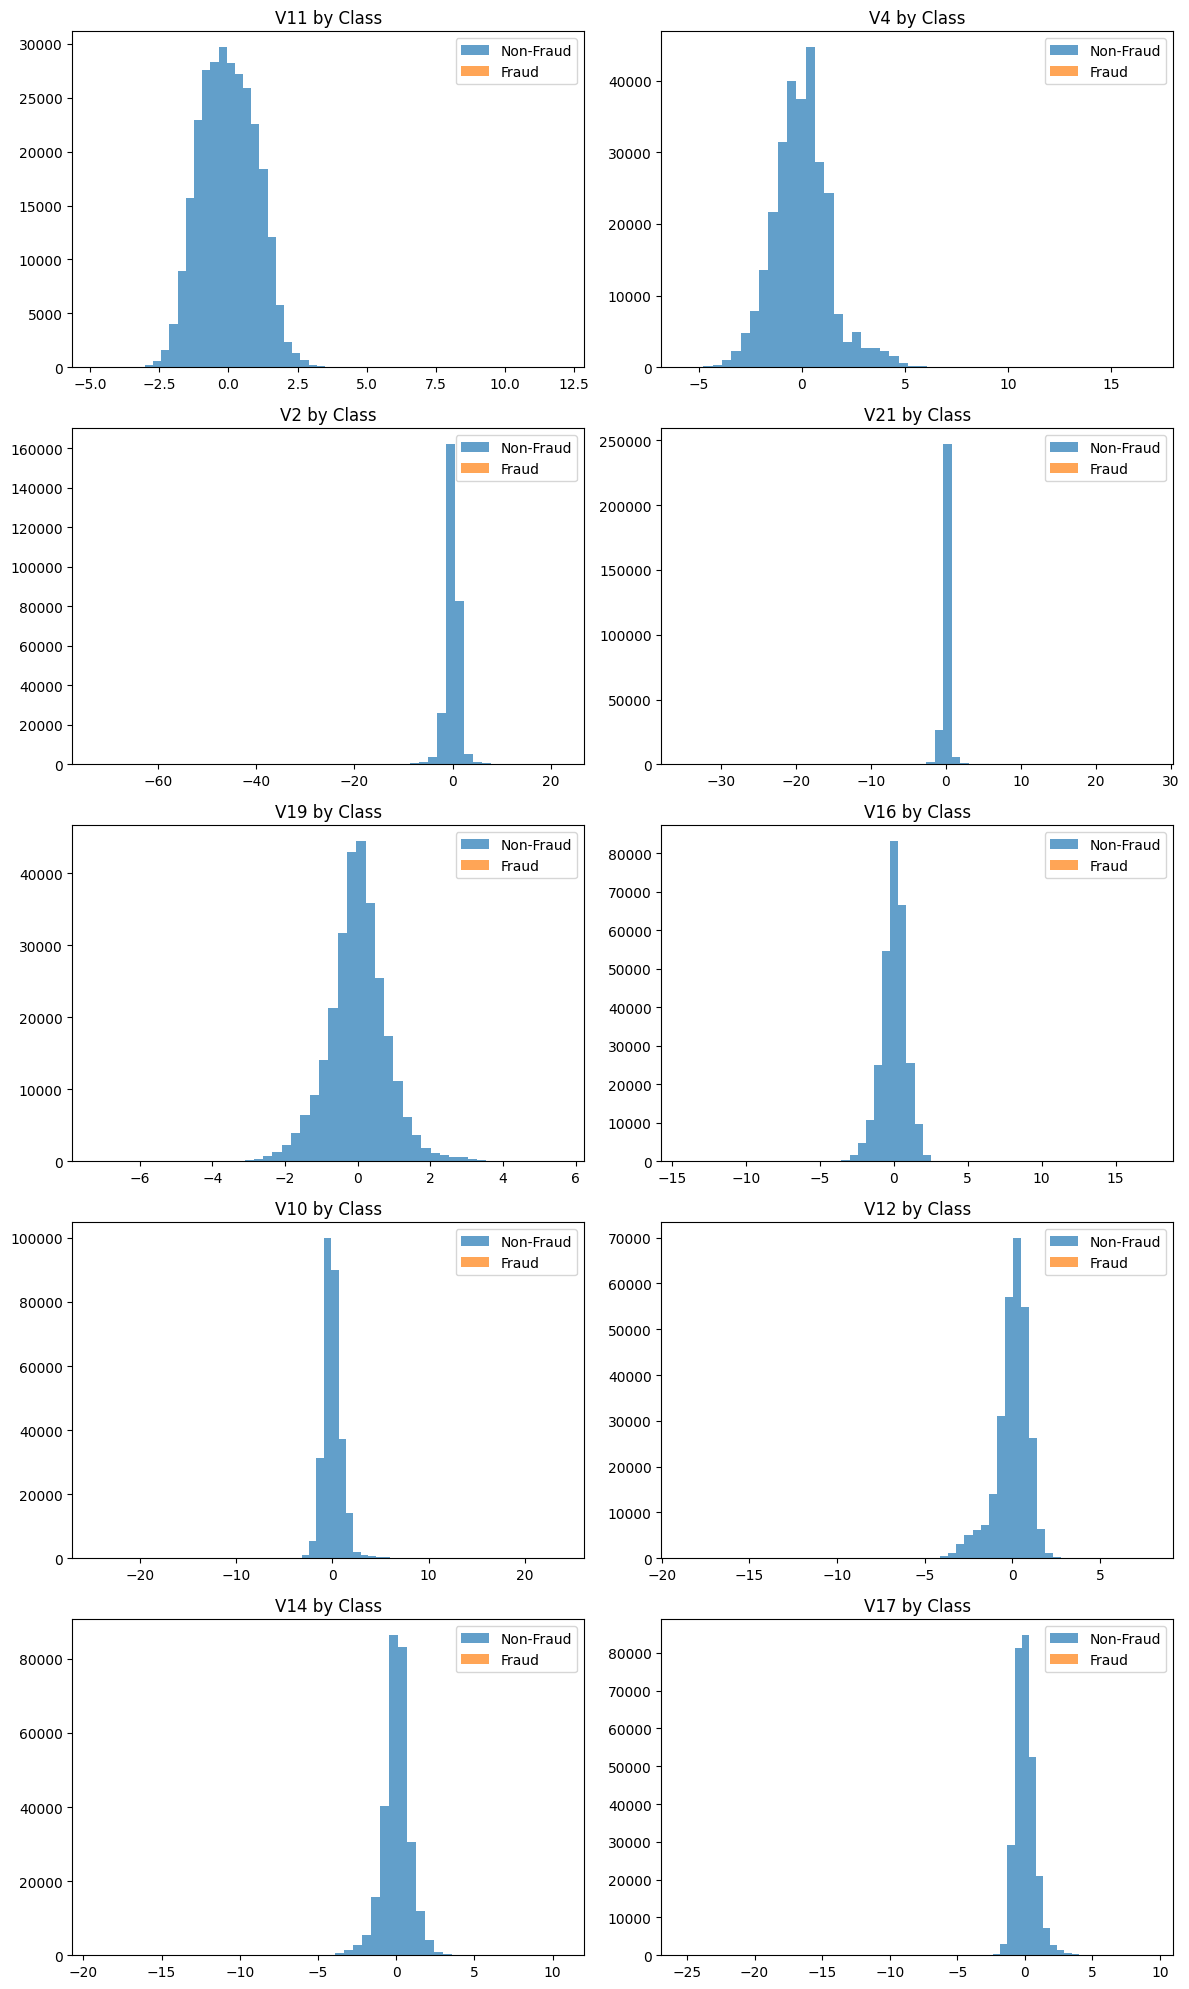

In [17]:
top_positive = corr_with_target.drop("Class").head(5).index.tolist()
top_negative = corr_with_target.tail(5).index.tolist()
selected_features = top_positive + top_negative

n_rows = int(np.ceil(len(selected_features) / 2))
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(selected_features):
    fraud_vals = df.loc[df["Class"] == 1, col]
    nonfraud_vals = df.loc[df["Class"] == 0, col]
    
    axes[i].hist(nonfraud_vals, bins=50, alpha=0.7, label="Non-Fraud")
    axes[i].hist(fraud_vals, bins=50, alpha=0.7, label="Fraud")
    axes[i].set_title(f"{col} by Class")
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

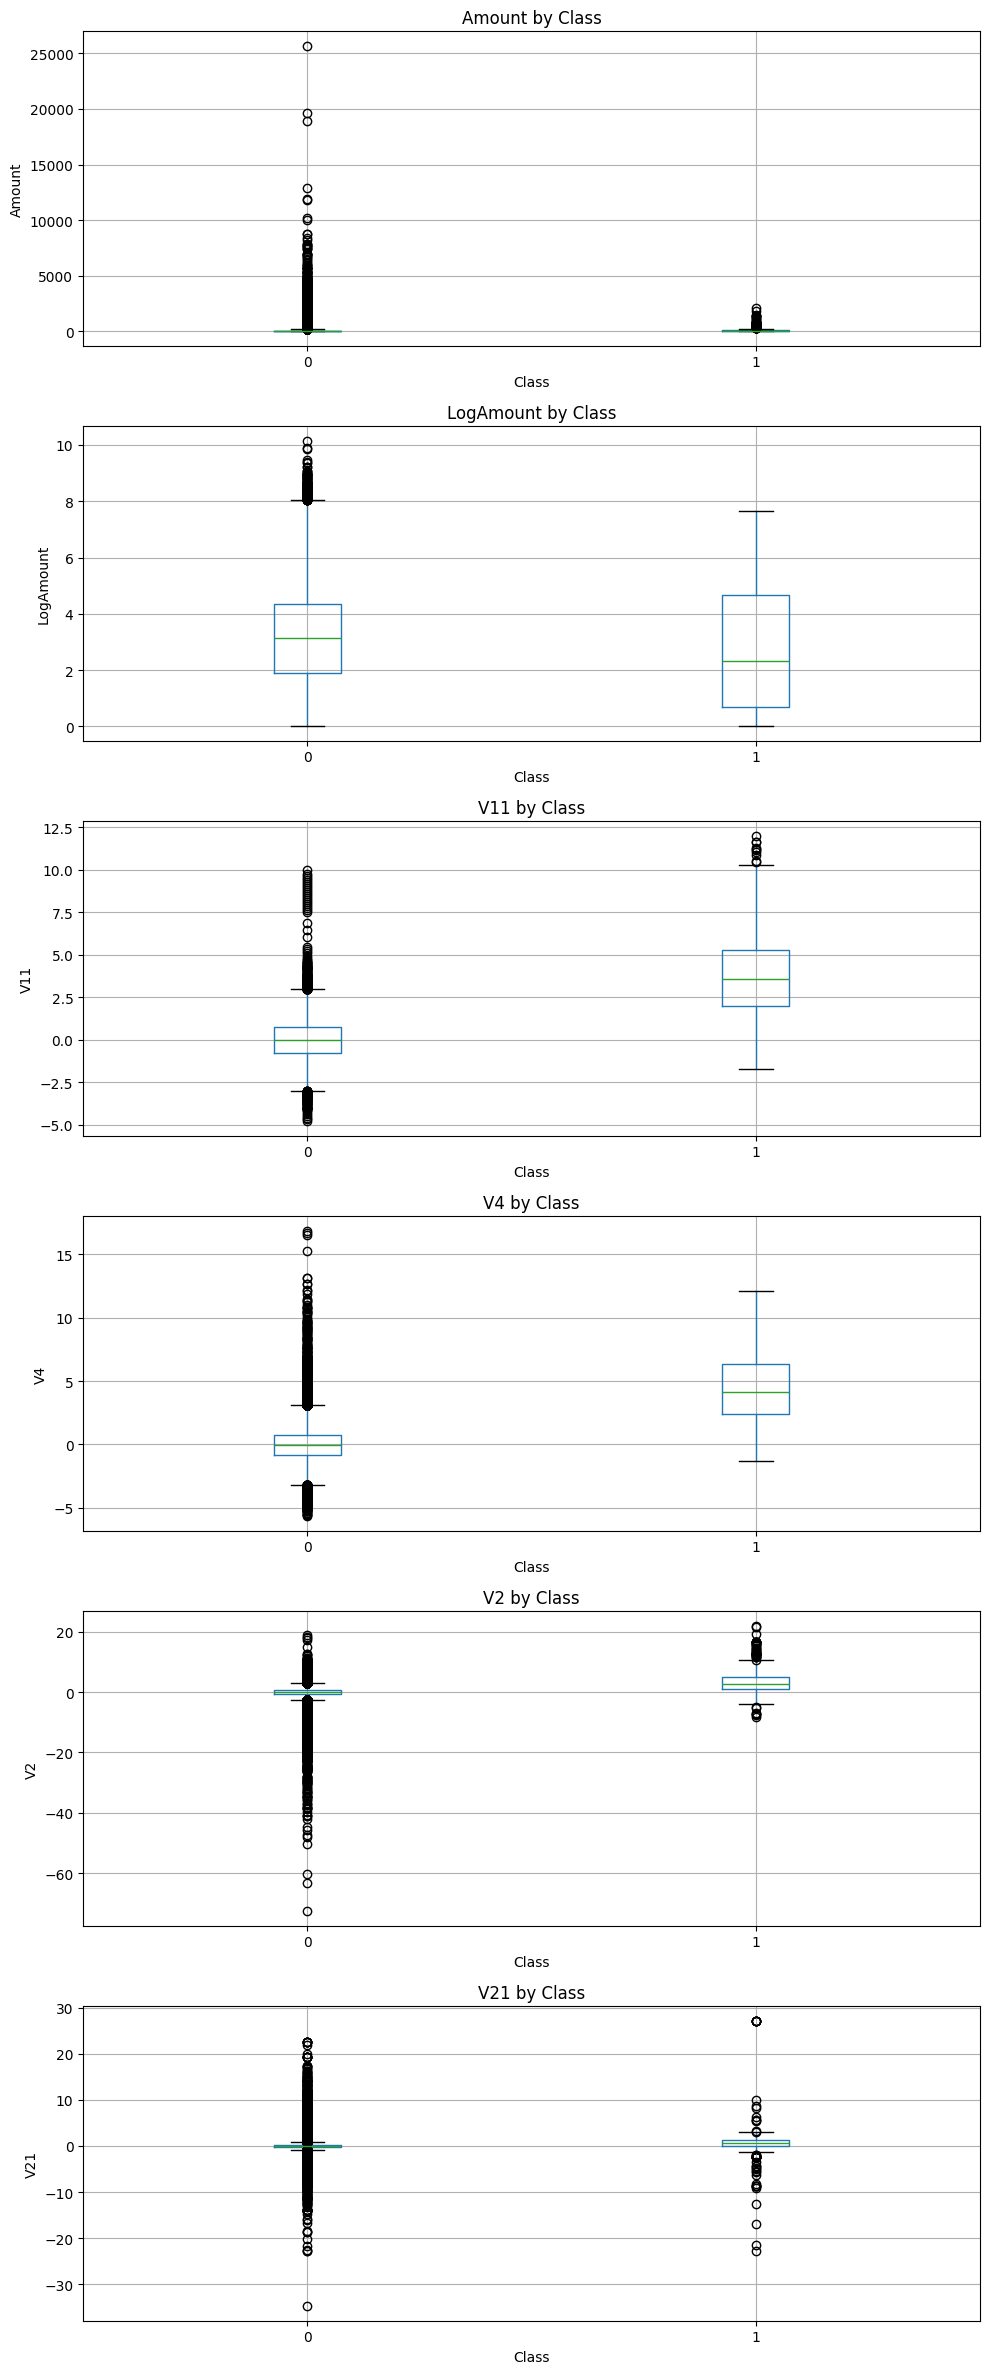

In [18]:
selected_boxplot_features = ["Amount", "LogAmount"] + selected_features[:4]

fig, axes = plt.subplots(len(selected_boxplot_features), 1, figsize=(10, 4 * len(selected_boxplot_features)))

for ax, col in zip(axes, selected_boxplot_features):
    df.boxplot(column=col, by="Class", ax=ax)
    ax.set_title(f"{col} by Class")
    ax.set_xlabel("Class")
    ax.set_ylabel(col)

plt.suptitle("")
plt.tight_layout()
plt.show()

In [19]:
q1 = df["Amount"].quantile(0.25)
q3 = df["Amount"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = ((df["Amount"] < lower) | (df["Amount"] > upper)).sum()

print(f"Q1: {q1:.4f}")
print(f"Q3: {q3:.4f}")
print(f"IQR: {iqr:.4f}")
print(f"Lower bound: {lower:.4f}")
print(f"Upper bound: {upper:.4f}")
print(f"Potential outliers in Amount: {outliers}")

Q1: 5.6000
Q3: 77.1650
IQR: 71.5650
Lower bound: -101.7475
Upper bound: 184.5125
Potential outliers in Amount: 31904


In [20]:
print("EDA Summary")
print("-" * 50)
print(f"Dataset shape: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Fraud rate: {df['Class'].mean() * 100:.4f}%")
print()
print("Initial observations:")
print("1. The dataset is highly imbalanced.")
print("2. Amount is right-skewed; log transform helps visualization.")
print("3. Time can be converted into hour-based features.")
print("4. Some PCA-transformed features show separation between fraud and non-fraud.")
print("5. Class imbalance handling will be important during modeling.")

EDA Summary
--------------------------------------------------
Dataset shape: (284807, 33)
Duplicate rows: 1081
Missing values: 0
Fraud rate: 0.1727%

Initial observations:
1. The dataset is highly imbalanced.
2. Amount is right-skewed; log transform helps visualization.
3. Time can be converted into hour-based features.
4. Some PCA-transformed features show separation between fraud and non-fraud.
5. Class imbalance handling will be important during modeling.
